# 1. Import

In [1]:
import cv2
import numpy as np
import os
from matplotlib import pyplot as plt
import time
import mediapipe as mp

# 2. Keypoints using MP Pose (เฉพาะ pose ไม่ประมวลผล face/hand จึงเร็วกว่า Holistic มาก)

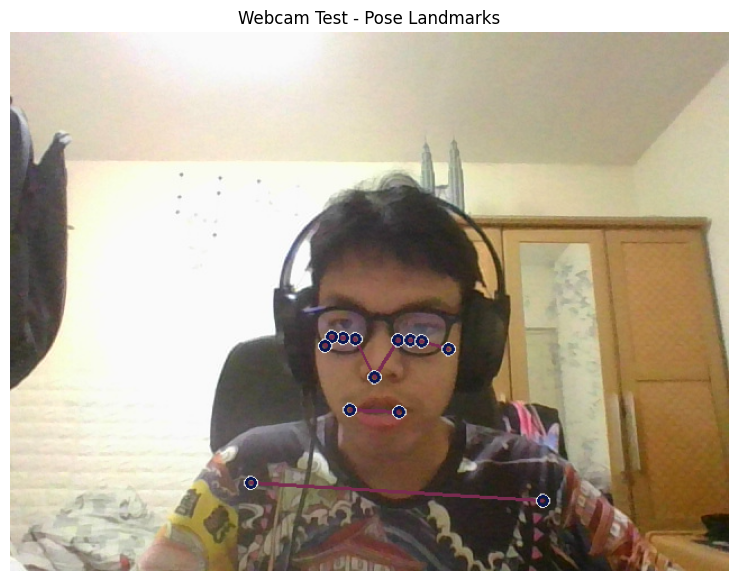

In [2]:
mp_pose = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils


def mediapipe_detection(image, model):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image.flags.writeable = False
    results = model.process(image)
    image.flags.writeable = True
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    return image, results


def draw_styled_landmarks(image, results):
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_pose.POSE_CONNECTIONS,
                             mp_drawing.DrawingSpec(color=(80, 22, 10), thickness=2, circle_radius=4),
                             mp_drawing.DrawingSpec(color=(80, 44, 121), thickness=2, circle_radius=2))


# ทดสอบจับภาพ 1 เฟรม แสดง inline
cap = cv2.VideoCapture(0)
with mp_pose.Pose(model_complexity=1, min_detection_confidence=0.5, min_tracking_confidence=0.5) as pose:
    ret, frame = cap.read()
    if ret:
        frame = cv2.flip(frame, 1)
        image, results = mediapipe_detection(frame, pose)
        draw_styled_landmarks(image, results)
        plt.figure(figsize=(10, 7))
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.title('Webcam Test - Pose Landmarks')
        plt.show()
    else:
        print('ERROR: ไม่สามารถเปิดกล้องได้')
cap.release()

# 3. เก็บ Pose ดิบ 33 จุด + ฟังก์ชันแปลงเป็น Feature

เก็บ landmark ดิบลงไฟล์ แล้วค่อยเลือกจุด / normalize / คำนวณ velocity ตอน preprocess
วิธีนี้ทำให้เปลี่ยน feature ได้ภายหลังโดยไม่ต้องอัดข้อมูลใหม่

In [3]:
# --- config ชุดข้อมูล (cell 7 ใช้ค่าพวกนี้ จึงต้องอยู่ที่นี่ ไม่ใช่ในเซลล์อัดข้อมูล) ---
DATA_PATH = os.path.join('MP_Data_Diag')
actions = np.array(['jab', 'cross', 'hook', 'uppercut', 'idle', 'block'])

N_RAW = 33 * 4          # pose ดิบทั้งหมด 33 จุด x (x, y, z, visibility)
FRAME_W, FRAME_H = 640, 480
ASPECT = FRAME_W / FRAME_H

# จุดที่เอามาทำ feature: ไหล่(11,12) ศอก(13,14) ข้อมือ(15,16) นิ้วชี้(19,20) สะโพก(23,24)
# สะโพกจำเป็นสำหรับอ้างอิงการบิดลำตัว ซึ่งเป็นตัวแยก hook ออกจาก uppercut
POSE_IDX = [11, 12, 13, 14, 15, 16, 19, 20, 23, 24]


def extract_raw_pose(results):
    if results.pose_landmarks:
        return np.array([[lm.x, lm.y, lm.z, lm.visibility]
                         for lm in results.pose_landmarks.landmark]).flatten()
    return np.zeros(N_RAW)


def build_features(raw_seq):
    """raw_seq: (T, 132) -> (T, F) ผ่าน normalize + velocity"""
    raw_seq = np.asarray(raw_seq, dtype=np.float32)
    lm = raw_seq.reshape(len(raw_seq), 33, 4)
    xyz = lm[:, :, :3].copy()
    xyz[:, :, 0] *= ASPECT              # แก้สัดส่วนภาพ ไม่งั้นระยะทางเพี้ยน

    mid_hip = (xyz[:, 23] + xyz[:, 24]) / 2
    mid_sh = (xyz[:, 11] + xyz[:, 12]) / 2
    # ใช้ความยาวลำตัวเป็น scale เพราะความกว้างไหล่หดตอนบิดตัว
    scale = np.linalg.norm(mid_sh - mid_hip, axis=1, keepdims=True)
    scale = np.maximum(scale, 1e-6)

    norm = (xyz - mid_hip[:, None, :]) / scale[:, None, :]
    pos = norm[:, POSE_IDX, :].reshape(len(raw_seq), -1)

    vel = np.zeros_like(pos)
    vel[1:] = np.diff(pos, axis=0)      # velocity แยก uppercut (พุ่ง) ออกจาก block (นิ่ง)

    return np.concatenate([pos, vel], axis=1)


N_FEATURES = build_features(np.zeros((2, N_RAW))).shape[1]
print(f'raw per frame:      {N_RAW}')
print(f'features per frame: {N_FEATURES}  ({len(POSE_IDX)} จุด x 3 แกน x [pos, vel])')


raw per frame:      132
features per frame: 60  (10 จุด x 3 แกน x [pos, vel])


# 4. วัด FPS จริงของ loop (MediaPipe + กล้อง)

In [4]:
# ล็อกตายตัว ห้ามเปลี่ยนหลังอัด session แรกไปแล้ว
# ค่านี้เลือกไว้ราว 1.3 วินาที หลังเปลี่ยนมาใช้ mp.solutions.pose
sequence_length = 36

WARMUP_FRAMES = 10
MEASURE_FRAMES = 60

cap = cv2.VideoCapture(0)
frame_times = []

with mp_pose.Pose(model_complexity=1, min_detection_confidence=0.5, min_tracking_confidence=0.5) as pose:
    for i in range(WARMUP_FRAMES + MEASURE_FRAMES):
        t0 = time.time()
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.flip(frame, 1)
        image, results = mediapipe_detection(frame, pose)
        draw_styled_landmarks(image, results)
        extract_raw_pose(results)

        if i >= WARMUP_FRAMES:
            frame_times.append(time.time() - t0)

cap.release()

avg_time = np.mean(frame_times)
real_fps = 1.0 / avg_time

print(f'เวลาเฉลี่ยต่อเฟรม: {avg_time*1000:.1f} ms')
print(f'FPS จริงของ loop:   {real_fps:.1f}')
print(f'sequence_length:    {sequence_length} frames  ->  {sequence_length/real_fps:.2f}s')
print()
print('ถ้าเวลาไม่พอดี เลือกจากตารางนี้แล้วแก้ sequence_length ก่อนเริ่มอัด:')
for sec in (1.0, 1.2, 1.3, 1.5, 1.8):
    print(f'   {sec:.1f}s  ->  {round(sec * real_fps)} frames')


เวลาเฉลี่ยต่อเฟรม: 48.3 ms
FPS จริงของ loop:   20.7
sequence_length:    36 frames  ->  1.74s

ถ้าเวลาไม่พอดี เลือกจากตารางนี้แล้วแก้ sequence_length ก่อนเริ่มอัด:
   1.0s  ->  21 frames
   1.2s  ->  25 frames
   1.3s  ->  27 frames
   1.5s  ->  31 frames
   1.8s  ->  37 frames


# 5. กำหนด Session และสร้างโฟลเดอร์

อัดหลายรอบแยกกัน เปลี่ยน `SESSION` ทีละรอบ ระหว่างรอบให้**ลุกเดินออกไปแล้วกลับมายืนใหม่**
เปลี่ยนระยะห่างจากกล้อง มุม หรือแสง — ถ้ายืนจุดเดิมไม่ขยับ ข้อมูลจะรั่วเหมือนเดิม

In [5]:
no_sequences = 15    # คลิปต่อ 1 ท่า ต่อ 1 รอบ

SESSION = None       # None = หาเลขว่างถัดไปให้เอง / ใส่เลขเองเฉพาะตอนตั้งใจอัดทับ

os.makedirs(DATA_PATH, exist_ok=True)
done = sorted(int(d.split('_')[1]) for d in os.listdir(DATA_PATH) if d.startswith('session_'))

if SESSION is None:
    SESSION = (max(done) + 1) if done else 0

SESSION_PATH = os.path.join(DATA_PATH, f'session_{SESSION}')

print(f'session ที่อัดไว้แล้ว: {done if done else "ยังไม่มี"}')
print(f'รอบนี้จะอัดลง:        session_{SESSION}')
print(f'sequence_length:      {sequence_length} frames')
print(f'คลิปในรอบนี้:         {len(actions) * no_sequences}  ({len(actions)} ท่า x {no_sequences} คลิป)')

if SESSION in done:
    print(f'\n*** session_{SESSION} มีข้อมูลอยู่แล้ว เซลล์ 6 จะไม่ยอมอัดทับให้ ***')


session ที่อัดไว้แล้ว: [0, 1, 2, 3]
รอบนี้จะอัดลง:        session_4
sequence_length:      36 frames
คลิปในรอบนี้:         90  (6 ท่า x 15 คลิป)


# 6. เก็บ Dataset

In [ ]:
ALLOW_OVERWRITE = False   # ตั้ง True เฉพาะตอนตั้งใจอัดทับ session เดิมจริงๆ

if os.path.isdir(SESSION_PATH) and not ALLOW_OVERWRITE:
    raise RuntimeError(
        f'{SESSION_PATH} มีข้อมูลอยู่แล้ว\n'
        f'-> กดรันเซลล์ 5 ใหม่เพื่อเลื่อนไป session ถัดไป\n'
        f'-> หรือตั้ง ALLOW_OVERWRITE = True ถ้าตั้งใจจะอัดทับ'
    )

WIN = 'OpenCV Feed'
START_DELAY = 10     # วินาที รอเดินไปยืนหน้ากล้องตอนเริ่ม
ACTION_DELAY = 6     # วินาที ตอนเปลี่ยนท่า
CLIP_DELAY = 3       # วินาที ระหว่างคลิป


def open_window():
    cv2.namedWindow(WIN, cv2.WINDOW_NORMAL)
    cv2.resizeWindow(WIN, 960, 720)
    cv2.moveWindow(WIN, 60, 30)
    try:
        cv2.setWindowProperty(WIN, cv2.WND_PROP_TOPMOST, 1)   # ดึงหน้าต่างขึ้นหน้าสุด
    except Exception:
        pass
    for _ in range(5):
        cv2.waitKey(1)


def draw_hud(image, action, clip, big=None, recording=False):
    cv2.putText(image, action.upper(), (15, 50),
                cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 255, 255), 4, cv2.LINE_AA)
    cv2.putText(image, f'clip {clip}/{no_sequences}   session {SESSION}', (15, 82),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2, cv2.LINE_AA)
    if big:
        cv2.putText(image, big, (255, 330),
                    cv2.FONT_HERSHEY_SIMPLEX, 7, (0, 255, 0), 14, cv2.LINE_AA)
    if recording:
        cv2.circle(image, (600, 40), 16, (0, 0, 255), -1)
        cv2.putText(image, 'REC', (505, 52),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 0, 255), 3, cv2.LINE_AA)
    cv2.imshow(WIN, image)


def countdown(cap, pose, action, clip, seconds):
    t_end = time.time() + seconds
    while time.time() < t_end:
        ret, frame = cap.read()
        if not ret:
            continue
        frame = cv2.flip(frame, 1)
        image, results = mediapipe_detection(frame, pose)
        draw_styled_landmarks(image, results)
        draw_hud(image, action, clip, big=str(int(np.ceil(t_end - time.time()))))
        if cv2.waitKey(1) & 0xFF == ord('q'):
            return False
    return True


for action in actions:
    for sequence in range(no_sequences):
        os.makedirs(os.path.join(SESSION_PATH, action, str(sequence)), exist_ok=True)

cap = cv2.VideoCapture(0)
aborted = False
first = True

try:
    open_window()
    with mp_pose.Pose(model_complexity=1, min_detection_confidence=0.5, min_tracking_confidence=0.5) as pose:
        for action in actions:
            for sequence in range(no_sequences):
                if first:
                    delay = START_DELAY
                elif sequence == 0:
                    delay = ACTION_DELAY
                else:
                    delay = CLIP_DELAY
                first = False

                if not countdown(cap, pose, action, sequence + 1, delay):
                    aborted = True
                    break

                for frame_num in range(sequence_length):
                    ret, frame = cap.read()
                    if not ret:
                        continue
                    frame = cv2.flip(frame, 1)
                    image, results = mediapipe_detection(frame, pose)
                    draw_styled_landmarks(image, results)
                    draw_hud(image, action, sequence + 1, recording=True)

                    np.save(os.path.join(SESSION_PATH, action, str(sequence), str(frame_num)),
                            extract_raw_pose(results))

                    if cv2.waitKey(1) & 0xFF == ord('q'):
                        aborted = True
                        break

                if aborted:
                    break
            if aborted:
                break
finally:
    cap.release()
    cv2.destroyAllWindows()

print('หยุดกลางคัน' if aborted else f'เก็บ session {SESSION} ครบแล้ว')


# 7. Preprocess — แบ่ง train/test ตาม Session

แบ่งตามรอบที่อัด ไม่ใช่สุ่ม เพราะคลิปในรอบเดียวกันคล้ายกันเกินไป
ถ้าสุ่มแบ่ง โมเดลจะเห็นคลิปข้างเคียงใน train แล้วทำคะแนน test สูงแบบหลอกๆ

In [6]:
from tensorflow.keras.utils import to_categorical

TRAIN_SESSIONS = [0, 1]
VAL_SESSIONS = [2]
TEST_SESSIONS = [3]

# เลื่อนตำแหน่งหมัดใน window เพื่อให้โมเดลได้เห็น "ครึ่งหมัด" แบบที่เจอตอนเล่นจริง
# ตอนเล่น window เลื่อนทีละเฟรม ส่วนใหญ่จึงจับหมัดได้ไม่เต็ม ซึ่งโมเดลไม่เคยเห็นมาก่อน
# เลื่อนแค่ราว +-25% ของ window ถ้าเลื่อนมากกว่านี้จะเหลือแต่ท่าการ์ดแต่ยังติดป้ายว่าเป็นหมัด
SHIFTS = (-9, -4, 0, 4, 9)

label_map = {label: num for num, label in enumerate(actions)}


def shift_clip(raw, k):
    """เลื่อนคลิปไป k เฟรม เติมขอบด้วยเฟรมแรก/สุดท้าย (ซึ่งเป็นท่าการ์ด)"""
    arr = np.asarray(raw, dtype=np.float32)
    idx = np.clip(np.arange(len(arr)) - k, 0, len(arr) - 1)
    return arr[idx]


def load_sessions(session_ids, shifts=(0,)):
    Xs, ys = [], []
    for sid in session_ids:
        spath = os.path.join(DATA_PATH, f'session_{sid}')
        if not os.path.isdir(spath):
            print(f'  ข้าม session_{sid} (ยังไม่มี)')
            continue
        for action in actions:
            apath = os.path.join(spath, action)
            for seq in sorted(os.listdir(apath), key=int):
                raw = [np.load(os.path.join(apath, seq, f'{f}.npy'))
                       for f in range(sequence_length)]
                for k in shifts:
                    Xs.append(build_features(shift_clip(raw, k)))
                    ys.append(label_map[action])
    return np.array(Xs, dtype=np.float32), to_categorical(ys, len(actions)).astype(int)


X_train, y_train = load_sessions(TRAIN_SESSIONS, SHIFTS)   # เฉพาะ train ที่เพิ่มคลิป
X_val, y_val = load_sessions(VAL_SESSIONS)                  # val/test ไม่เลื่อน จะได้เทียบกับผลเดิมได้
X_test, y_test = load_sessions(TEST_SESSIONS)

print(f'train {X_train.shape}  sessions={TRAIN_SESSIONS}  x{len(SHIFTS)} shifts')
print(f'val   {X_val.shape}  sessions={VAL_SESSIONS}')
print(f'test  {X_test.shape}  sessions={TEST_SESSIONS}')


train (900, 36, 60)  sessions=[0, 1]  x5 shifts
val   (90, 36, 60)  sessions=[2]
test  (90, 36, 60)  sessions=[3]


# 8. Build and Train LSTM

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=40, restore_best_weights=True)

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(sequence_length, N_FEATURES)),
    Dropout(0.3),
    LSTM(32),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(len(actions), activation='softmax'),
])

model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['categorical_accuracy'])
model.summary()

model.fit(X_train, y_train, epochs=500, batch_size=16,
          validation_data=(X_val, y_val), callbacks=[early_stop])



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 36, 64)            32000     
                                                                 
 dropout (Dropout)           (None, 36, 64)            0         
                                                                 
 lstm_1 (LSTM)               (None, 32)                12416     
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                                 
 dense (Dense)               (None, 32)                1056      
                                                                 
 dense_1 (Dense)             (None, 6)                 198       
                                                                 
Total params: 45670 (178.40 KB)
Trainable params: 4567

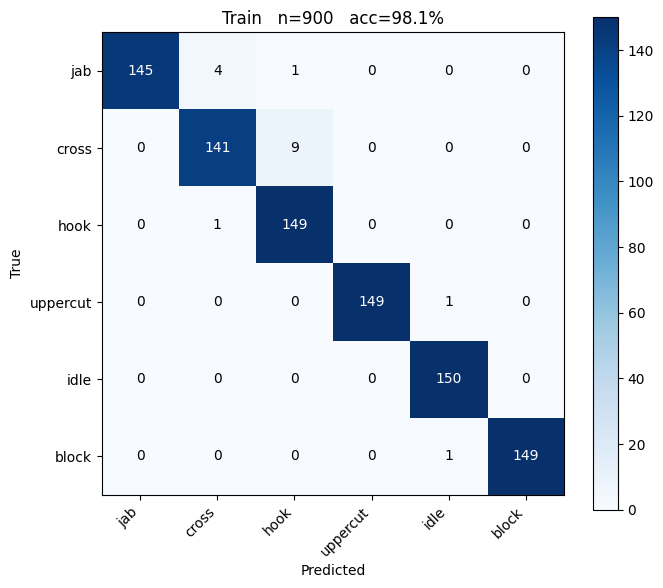

===== Train =====
              precision    recall  f1-score   support

         jab       1.00      0.97      0.98       150
       cross       0.97      0.94      0.95       150
        hook       0.94      0.99      0.96       150
    uppercut       1.00      0.99      1.00       150
        idle       0.99      1.00      0.99       150
       block       1.00      0.99      1.00       150

    accuracy                           0.98       900
   macro avg       0.98      0.98      0.98       900
weighted avg       0.98      0.98      0.98       900



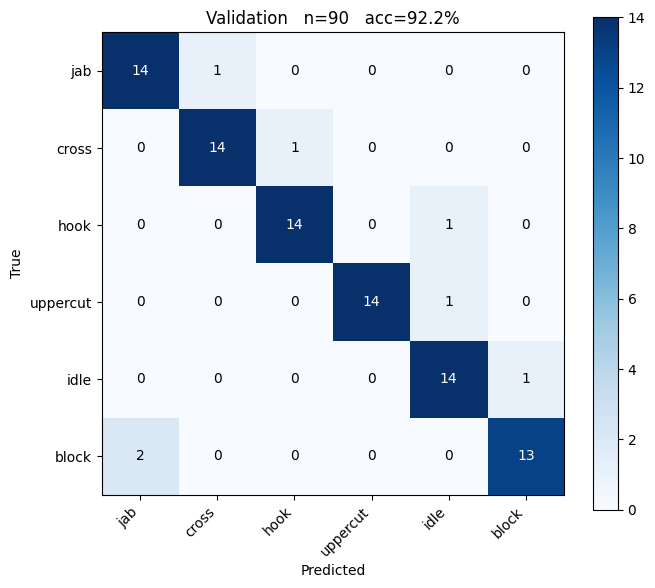

===== Validation =====
              precision    recall  f1-score   support

         jab       0.88      0.93      0.90        15
       cross       0.93      0.93      0.93        15
        hook       0.93      0.93      0.93        15
    uppercut       1.00      0.93      0.97        15
        idle       0.88      0.93      0.90        15
       block       0.93      0.87      0.90        15

    accuracy                           0.92        90
   macro avg       0.92      0.92      0.92        90
weighted avg       0.92      0.92      0.92        90



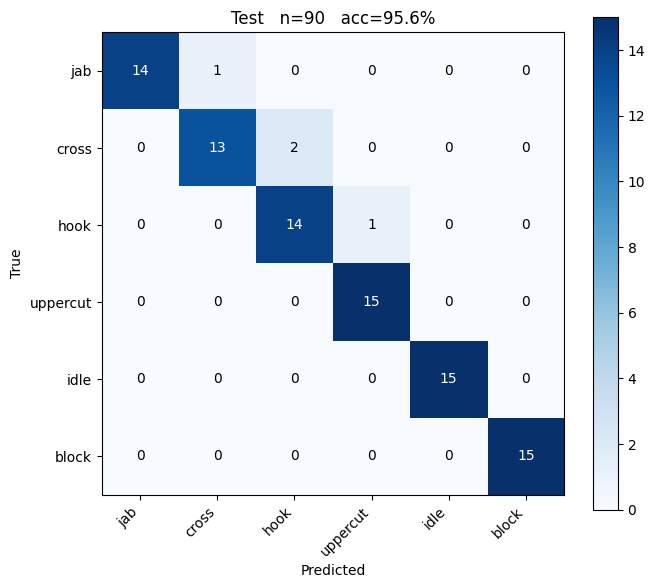

===== Test =====
              precision    recall  f1-score   support

         jab       1.00      0.93      0.97        15
       cross       0.93      0.87      0.90        15
        hook       0.88      0.93      0.90        15
    uppercut       0.94      1.00      0.97        15
        idle       1.00      1.00      1.00        15
       block       1.00      1.00      1.00        15

    accuracy                           0.96        90
   macro avg       0.96      0.96      0.96        90
weighted avg       0.96      0.96      0.96        90



In [8]:
from sklearn.metrics import confusion_matrix, classification_report

def show_confusion(X, y_onehot, title):
    y_true = np.argmax(y_onehot, axis=1)
    y_pred = np.argmax(model.predict(X, verbose=0), axis=1)
    idx = list(range(len(actions)))
    cm = confusion_matrix(y_true, y_pred, labels=idx)
    acc = np.mean(y_pred == y_true)

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(idx)
    ax.set_xticklabels(actions, rotation=45, ha='right')
    ax.set_yticks(idx)
    ax.set_yticklabels(actions)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'{title}   n={len(y_true)}   acc={acc:.1%}')

    thresh = cm.max() / 2 if cm.max() > 0 else 0.5
    for i in idx:
        for j in idx:
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color='white' if cm[i, j] > thresh else 'black')
    fig.colorbar(im)
    plt.tight_layout()
    plt.show()

    print(f'===== {title} =====')
    print(classification_report(y_true, y_pred, labels=idx,
                                target_names=list(actions), zero_division=0))

show_confusion(X_train, y_train, 'Train')
show_confusion(X_val, y_val, 'Validation')
show_confusion(X_test, y_test, 'Test')

# 9. Test

In [9]:
colors = [(245, 117, 16), (117, 245, 16), (16, 117, 245),
          (255, 55, 55), (180, 180, 180), (55, 255, 255)]


def prob_viz(res, actions, input_frame, colors):
    output_frame = input_frame.copy()
    for num, prob in enumerate(res):
        cv2.rectangle(output_frame, (0, 60 + num * 40), (int(prob * 100), 90 + num * 40), colors[num], -1)
        cv2.putText(output_frame, actions[num], (0, 85 + num * 40),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA)
    return output_frame


raw_buffer = []
sentence = []
predictions = []
threshold = 0.7
CONSENSUS = 3     # หมัดเร็วกินแค่ไม่กี่เฟรม ใช้ 10 เหมือนเดิมจะไม่มีทางครบ

cap = cv2.VideoCapture(0)
try:
    with mp_pose.Pose(model_complexity=1, min_detection_confidence=0.5, min_tracking_confidence=0.5) as pose:
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break
            frame = cv2.flip(frame, 1)

            image, results = mediapipe_detection(frame, pose)
            draw_styled_landmarks(image, results)

            raw_buffer.append(extract_raw_pose(results))
            raw_buffer = raw_buffer[-sequence_length:]

            if len(raw_buffer) == sequence_length:
                feats = build_features(raw_buffer)
                res = model.predict(np.expand_dims(feats, axis=0), verbose=0)[0]
                predictions.append(np.argmax(res))

                if len(predictions) >= CONSENSUS and len(set(predictions[-CONSENSUS:])) == 1:
                    if res[np.argmax(res)] > threshold:
                        word = actions[np.argmax(res)]
                        if len(sentence) == 0 or word != sentence[-1]:
                            sentence.append(word)

                sentence = sentence[-5:]
                image = prob_viz(res, actions, image, colors)

            cv2.rectangle(image, (0, 0), (640, 40), (245, 117, 16), -1)
            cv2.putText(image, ' '.join(sentence), (3, 30),
                        cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA)

            cv2.imshow('OpenCV Feed', image)

            if cv2.waitKey(10) & 0xFF == ord('q'):
                break
finally:
    cap.release()
    cv2.destroyAllWindows()